# Figure S6i — Axoaxonic synapses within 4 µm of each axodendritic synapse

For every axodendritic synapse on a manually traced sensory axon, how many axoaxonic
synapses lie within **4 µm of cable length**. Each dot is one axodendritic synapse.

Unlike panels b–h (which use the dSC1 volume), this uses the **dSC_APEX volumes**, in
which individual sensory subtypes are genetically labelled, traced in CATMAID. At least
five axons were sampled per subtype.

**Input.** `../data/catmaid_psi_within_4um/*_pre-vaxon_final.npz`, each holding a
`psi_close` array of per-axodendritic-synapse counts. **Runs offline.**

**Statistics.** Kruskal–Wallis followed by Dunn post hoc with **Bonferroni** correction.
Note this differs from Figures 3d/3e/3g, which use Holm; Bonferroni is what reproduces the
published p-values (6.38 × 10⁻⁶⁰, 5.41 × 10⁻¹², 1).


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 6

CM = 1 / 2.54


In [2]:
from pathlib import Path

import numpy as np

NPZ_DIR = Path("../data/catmaid_psi_within_4um")

# file stem -> published label. Note trpm8_deep duplicates trpm8 and is not used.
FILES = [
    ("abltmr",      "Aβ-LTMR"),
    ("trkb",        "Aδ-LTMR"),
    ("cltmr",       "C-LTMR"),
    ("mrgd",        "C-HTMR/Heat (MrgprD+)"),
    ("a3",          "C-HTMR/Heat (MrgprA3+)"),
    ("cysltr2",     "C-HTMR/Heat (SST+)"),
    ("smr2_super",  "Aδ-HTMR (dorsal)"),
    ("smr2_deep",   "Aδ-HTMR (ventral)"),
    ("sstr2",       "C-Heat (SSTR2+)"),
    ("trpm8",       "C-Cold (Trpm8+)"),
]

PALETTE = {
    "Aβ-LTMR":                 "#556B2F",
    "Aδ-LTMR":                 "#00A86B",
    "C-LTMR":                  "#BCEBCB",
    "C-HTMR/Heat (MrgprD+)":   "#b23aee",
    "C-HTMR/Heat (MrgprA3+)":  "#9467bd",
    "C-HTMR/Heat (SST+)":      "#ffbbff",
    "Aδ-HTMR (dorsal)":        "#ff4040",
    "Aδ-HTMR (ventral)":       "#eb5324",
    "C-Heat (SSTR2+)":         "#ffee00",
    "C-Cold (Trpm8+)":         "#00bfff",
}

data, labels = [], []
for stem, label in FILES:
    arr = np.load(NPZ_DIR / f"{stem}_pre-vaxon_final.npz")["psi_close"].astype(float)
    data.append(arr)
    labels.append(label)
    print(f"{label:28s} n = {arr.size:4d}  mean = {arr.mean():5.2f}  "
          f"median = {np.median(arr):4.1f}")


Aβ-LTMR                      n =  644  mean =  9.37  median =  9.0
Aδ-LTMR                      n =  765  mean =  3.81  median =  3.0
C-LTMR                       n =  535  mean =  3.77  median =  4.0
C-HTMR/Heat (MrgprD+)        n =  429  mean =  4.13  median =  4.0
C-HTMR/Heat (MrgprA3+)       n =  462  mean =  1.01  median =  1.0
C-HTMR/Heat (SST+)           n =  124  mean =  0.00  median =  0.0
Aδ-HTMR (dorsal)             n =  195  mean =  3.78  median =  3.0
Aδ-HTMR (ventral)            n =  143  mean =  1.49  median =  1.0
C-Heat (SSTR2+)              n =  115  mean =  0.04  median =  0.0
C-Cold (Trpm8+)              n =  139  mean =  1.04  median =  1.0


In [3]:
import pandas as pd
import scikit_posthocs as sp
from scipy.stats import kruskal

H, p = kruskal(*data)
print(f"Kruskal-Wallis: H = {H:.4g}, p = {p:.4g}")

long_df = pd.DataFrame([{"group": lab, "value": v}
                        for lab, arr in zip(labels, data) for v in arr])
# NOTE: this panel uses Bonferroni correction, unlike Figures 3d/3e/3g which use Holm.
# Bonferroni is what reproduces the published p-values exactly.
dunn = sp.posthoc_dunn(long_df, val_col="value", group_col="group",
                       p_adjust="bonferroni")
dunn


Kruskal-Wallis: H = 1883, p = 0


,Aβ-LTMR,Aδ-HTMR (dorsal),Aδ-HTMR (ventral),Aδ-LTMR,C-Cold (Trpm8+),C-HTMR/Heat (MrgprA3+),C-HTMR/Heat (MrgprD+),C-HTMR/Heat (SST+),C-Heat (SSTR2+),C-LTMR
Aβ-LTMR,1.000000e+00,3.668643e-33,7.090802e-85,9.773423e-77,5.708676e-103,5.326660e-244,8.874378e-49,3.600363e-144,9.434171e-133,2.498916e-64
Aδ-HTMR (dorsal),3.668643e-33,1.000000e+00,5.407747e-12,1.000000e+00,1.127375e-18,3.849610e-32,1.000000e+00,4.145434e-38,3.140716e-35,1.000000e+00
Aδ-HTMR (ventral),7.090802e-85,5.407747e-12,1.000000e+00,9.901631e-18,1.000000e+00,1.000000e+00,1.144582e-18,5.458115e-07,3.168662e-06,1.501612e-16
Aδ-LTMR,9.773423e-77,1.000000e+00,9.901631e-18,1.000000e+00,2.815882e-27,7.204065e-68,1.000000e+00,7.372122e-54,6.877260e-49,1.000000e+00
C-Cold (Trpm8+),5.708676e-103,1.127375e-18,1.000000e+00,2.815882e-27,1.000000e+00,1.000000e+00,7.441201e-28,3.254446e-03,9.774076e-03,1.595841e-25
C-HTMR/Heat (MrgprA3+),5.326660e-244,3.849610e-32,1.000000e+00,7.204065e-68,1.000000e+00,1.000000e+00,6.381463e-60,8.918654e-05,5.237591e-04,2.675841e-58
C-HTMR/Heat (MrgprD+),8.874378e-49,1.000000e+00,1.144582e-18,1.000000e+00,7.441201e-28,6.381463e-60,1.000000e+00,3.018762e-53,1.050760e-48,1.000000e+00
C-HTMR/Heat (SST+),3.600363e-144,4.145434e-38,5.458115e-07,7.372122e-54,3.254446e-03,8.918654e-05,3.018762e-53,1.000000e+00,1.000000e+00,9.764509e-51
C-Heat (SSTR2+),9.434171e-133,3.140716e-35,3.168662e-06,6.877260e-49,9.774076e-03,5.237591e-04,1.050760e-48,1.000000e+00,1.000000e+00,3.224605e-46
C-LTMR,2.498916e-64,1.000000e+00,1.501612e-16,1.000000e+00,1.595841e-25,2.675841e-58,1.000000e+00,9.764509e-51,3.224605e-46,1.000000e+00


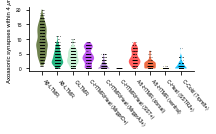

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.0 * CM, 5.0 * CM))
x = np.arange(1, len(data) + 1)

parts = ax.violinplot(data, positions=x, widths=0.75,
                      showmeans=False, showmedians=True, showextrema=False)
for body, lab in zip(parts["bodies"], labels):
    body.set_facecolor(PALETTE[lab])
    body.set_edgecolor("none")
    body.set_alpha(0.85)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(0.8)

rng = np.random.default_rng(0)
for i, arr in enumerate(data):
    ax.scatter(x[i] + rng.uniform(-0.15, 0.15, arr.size), arr,
               s=0.6, color="black", alpha=0.3, linewidths=0, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=-50, ha="left", fontsize=5)
ax.set_ylabel("Axoaxonic synapses within 4 µm", fontsize=6)
ax.tick_params(axis="y", labelsize=5)
ax.grid(False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("figureS6i_axoaxonic_within_4um.svg", format="svg", dpi=300)
plt.show()


In [5]:
# The three comparisons quoted in the legend.
for a, b in [("C-HTMR/Heat (MrgprD+)", "C-HTMR/Heat (MrgprA3+)"),
             ("Aδ-HTMR (dorsal)", "Aδ-HTMR (ventral)"),
             ("Aδ-HTMR (ventral)", "C-Cold (Trpm8+)")]:
    print(f"{a:26s} vs {b:26s} p = {dunn.loc[a, b]:.3g}")


C-HTMR/Heat (MrgprD+)      vs C-HTMR/Heat (MrgprA3+)     p = 6.38e-60
Aδ-HTMR (dorsal)           vs Aδ-HTMR (ventral)          p = 5.41e-12
Aδ-HTMR (ventral)          vs C-Cold (Trpm8+)            p = 1
